<a href="https://colab.research.google.com/github/dayniia/aml-cross-border-project/blob/main/notebooks/01_domain_eda_split.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
DATA_DIR = '/content/drive/MyDrive/AML_Dataset/'
!ls {DATA_DIR}

HI-Small_accounts.csv  HI-Small_Patterns.txt  HI-Small_Trans.csv  src


In [3]:
!ls {DATA_DIR}src

split_data.py


In [4]:
!cat {DATA_DIR}src/split_data.py

import pandas as pd

def temporal_split(df, timestamp_col='Timestamp', test_frac=0.2):
    df = df.sort_values(timestamp_col).reset_index(drop=True)
    split_idx = int(len(df) * (1 - test_frac))
    train = df.iloc[:split_idx].copy()
    test = df.iloc[split_idx:].copy()
    return train, test


In [5]:
%%writefile /content/drive/MyDrive/AML_Dataset/src/split_data.py
import pandas as pd


def temporal_split(df, timestamp_col='Timestamp', test_frac=0.2):
    """Sort by time and split so test is strictly later than train.

    Never use a random split for this project — a random split would leak
    future transaction information into training, which is not a realistic
    or valid way to evaluate a fraud/AML detection model.
    """
    df = df.sort_values(timestamp_col).reset_index(drop=True)
    split_idx = int(len(df) * (1 - test_frac))
    train = df.iloc[:split_idx].copy()
    test = df.iloc[split_idx:].copy()
    return train, test

Overwriting /content/drive/MyDrive/AML_Dataset/src/split_data.py


In [6]:
!cat {DATA_DIR}src/split_data.py

import pandas as pd


def temporal_split(df, timestamp_col='Timestamp', test_frac=0.2):
    """Sort by time and split so test is strictly later than train.

    Never use a random split for this project — a random split would leak
    future transaction information into training, which is not a realistic
    or valid way to evaluate a fraud/AML detection model.
    """
    df = df.sort_values(timestamp_col).reset_index(drop=True)
    split_idx = int(len(df) * (1 - test_frac))
    train = df.iloc[:split_idx].copy()
    test = df.iloc[split_idx:].copy()
    return train, test


In [7]:
%%writefile /content/drive/MyDrive/AML_Dataset/src/metrics.py
from sklearn.metrics import average_precision_score, precision_recall_curve, f1_score


def evaluate(y_true, y_prob, threshold=0.5):
    """Headline metrics for imbalanced AML classification.

    Accuracy is deliberately excluded from this project's evaluation. With an
    illicit rate of roughly 0.1%, a model that always predicts "not laundering"
    would score above 99.9% accuracy while catching zero real cases — so
    accuracy would be actively misleading here.

    Returns:
        dict with:
          - auprc: area under the precision-recall curve
          - minority_f1: F1 score on the illicit (minority) class
          - pr_curve: (precision, recall, thresholds) arrays for plotting
    """
    auprc = average_precision_score(y_true, y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    minority_f1 = f1_score(y_true, y_pred, pos_label=1)
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    return {
        "auprc": auprc,
        "minority_f1": minority_f1,
        "pr_curve": (precision, recall, thresholds),
    }

Writing /content/drive/MyDrive/AML_Dataset/src/metrics.py


In [8]:
!ls {DATA_DIR}src

metrics.py  split_data.py


In [9]:
import pandas as pd

trans = pd.read_csv(DATA_DIR + 'HI-Small_Trans.csv')
accounts = pd.read_csv(DATA_DIR + 'HI-Small_accounts.csv')

print(trans.shape)
print(trans.dtypes)
trans.head()

(5078345, 11)
Timestamp              object
From Bank               int64
Account                object
To Bank                 int64
Account.1              object
Amount Received       float64
Receiving Currency     object
Amount Paid           float64
Payment Currency       object
Payment Format         object
Is Laundering           int64
dtype: object


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [10]:
print(trans.isnull().sum())

trans['Timestamp'] = pd.to_datetime(trans['Timestamp'])

print(trans['Is Laundering'].value_counts(normalize=True) * 100)
print(trans['Timestamp'].min(), trans['Timestamp'].max())

Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64
Is Laundering
0    99.898057
1     0.101943
Name: proportion, dtype: float64
2022-09-01 00:00:00 2022-09-18 16:18:00


In [11]:
print(trans['Payment Currency'].value_counts())
print(trans['Payment Format'].value_counts())

Payment Currency
US Dollar            1895172
Euro                 1168297
Swiss Franc           234860
Yuan                  213752
Shekel                192184
Rupee                 190202
UK Pound              180738
Yen                   155209
Ruble                 155178
Bitcoin               146066
Canadian Dollar       140042
Australian Dollar     136769
Mexican Peso          110159
Saudi Riyal            89014
Brazil Real            70703
Name: count, dtype: int64
Payment Format
Cheque          1864331
Credit Card     1323324
ACH              600797
Cash             490891
Reinvestment     481056
Wire             171855
Bitcoin          146091
Name: count, dtype: int64


In [12]:
with open(DATA_DIR + 'HI-Small_Patterns.txt') as f:
    pattern_lines = f.readlines()

for line in pattern_lines[:15]:
    print(line.strip())

BEGIN LAUNDERING ATTEMPT - FAN-OUT:  Max 16-degree Fan-Out
2022/09/01 00:06,021174,800737690,012,80011F990,2848.96,Euro,2848.96,Euro,ACH,1
2022/09/01 04:33,021174,800737690,020,80020C5B0,8630.40,Euro,8630.40,Euro,ACH,1
2022/09/01 09:14,021174,800737690,020,80006A5E0,35642.49,Yuan,35642.49,Yuan,ACH,1
2022/09/01 09:56,021174,800737690,00220,8007A5B70,5738987.96,US Dollar,5738987.96,US Dollar,ACH,1
2022/09/01 11:28,021174,800737690,001244,80093C0D0,7254.53,US Dollar,7254.53,US Dollar,ACH,1
2022/09/01 13:13,021174,800737690,00513,80078E200,6990.87,US Dollar,6990.87,US Dollar,ACH,1
2022/09/01 14:11,021174,800737690,020,80066B990,12536.92,Euro,12536.92,Euro,ACH,1
2022/09/02 15:40,021174,800737690,00410,8002CC310,3511.82,Euro,3511.82,Euro,ACH,1
2022/09/02 21:23,021174,800737690,01292,8004030A0,16135.09,US Dollar,16135.09,US Dollar,ACH,1
2022/09/02 23:10,021174,800737690,01601,800578800,12183.28,US Dollar,12183.28,US Dollar,ACH,1
2022/09/03 09:29,021174,800737690,001,800AAF0B0,15197.45,US Doll

In [13]:
sample_account = '800737690'
flagged_txns = trans[(trans['Account'] == sample_account) | (trans['Account.1'] == sample_account)]
print(flagged_txns.shape)
flagged_txns['Payment Format'].value_counts()

(24, 11)


,count
Payment Format,
ACH,23
Reinvestment,1


In [18]:
print(flagged_txns[['Payment Currency', 'Amount Paid', 'Is Laundering']])
print(flagged_txns['Payment Currency'].value_counts())

format_rates = pd.crosstab(trans['Payment Format'], trans['Is Laundering'], normalize='index') * 100
print(format_rates)

ach = trans[trans['Payment Format'] == 'ACH'].copy()
ach_currency_rates = (
    pd.crosstab([trans['Payment Format'], trans['Payment Currency']], trans['Is Laundering'], normalize='index')[1]
    .sort_values(ascending=False)
    .head(10)
)
print(ach_currency_rates)

ach_counts = pd.crosstab([trans['Payment Format'], trans['Payment Currency']], trans['Is Laundering']).loc['ACH']
print(ach_counts)

from scipy.stats import chi2_contingency
ach['is_saudi'] = ach['Payment Currency'] == 'Saudi Riyal'
table = pd.crosstab(ach['is_saudi'], ach['Is Laundering'])
chi2, pval, dof, expected = chi2_contingency(table)
print(f"p-value: {pval:.2e}")

       Payment Currency  Amount Paid  Is Laundering
137519        US Dollar      3338.36              0
137520             Euro      2848.96              1
137521        US Dollar     10112.97              0
137522             Euro      8630.40              1
137523        US Dollar      5321.68              0
137524             Yuan     35642.49              1
137525        US Dollar   5738987.96              1
137526        US Dollar      7254.53              1
137527        US Dollar      6990.87              1
137528        US Dollar     14690.55              0
137529             Euro     12536.92              1
137530        US Dollar      4115.09              0
137531             Euro      3511.82              1
137532        US Dollar     16135.09              1
137533        US Dollar     12183.28              1
137534        US Dollar     15197.45              1
137535        US Dollar      4717.76              1
137536        US Dollar     19332.59              1
137537      

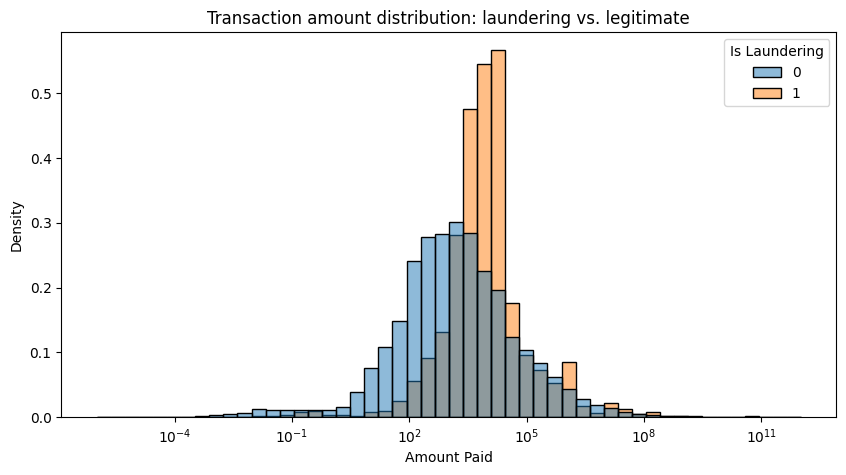

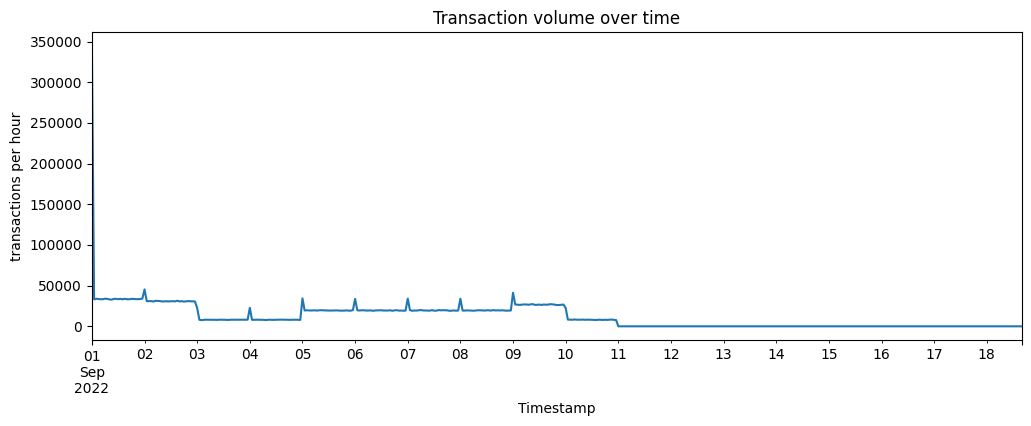

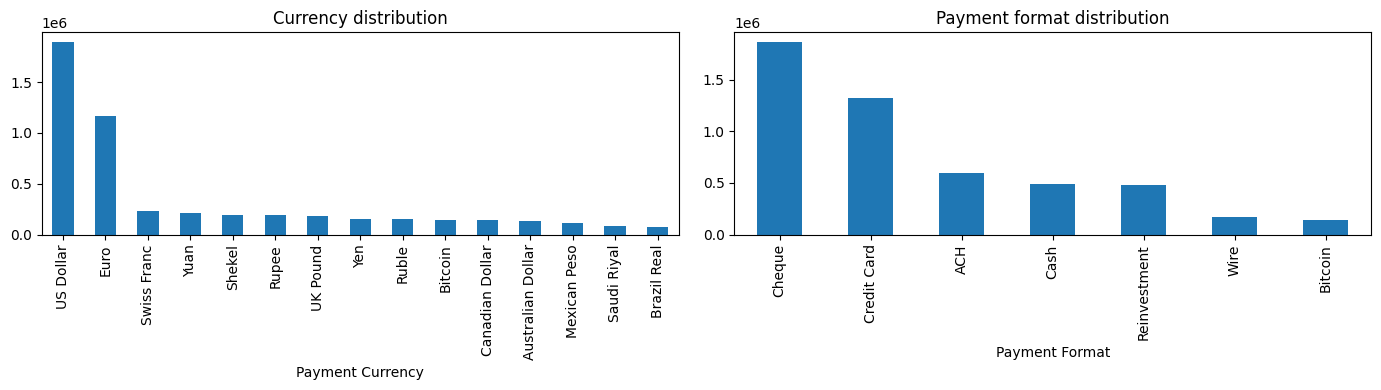

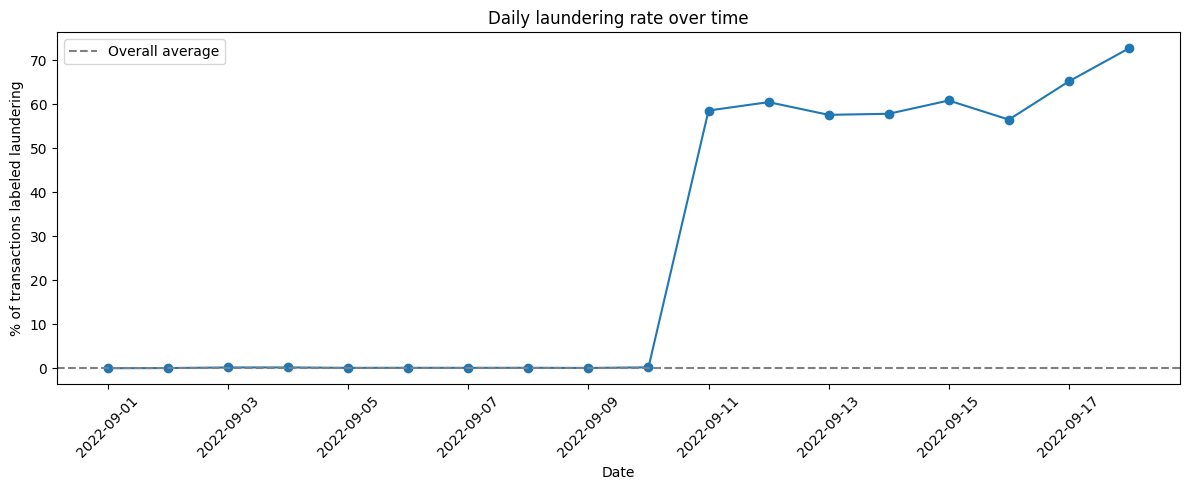

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(data=trans, x='Amount Paid', hue='Is Laundering', log_scale=True,
             stat='density', common_norm=False, bins=50)
plt.title('Transaction amount distribution: laundering vs. legitimate')
plt.show()
#/////////////
hourly = trans.set_index('Timestamp').resample('h').size()
plt.figure(figsize=(12, 4))
hourly.plot()
plt.title('Transaction volume over time')
plt.ylabel('transactions per hour')
plt.show()

#/////////////
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
trans['Payment Currency'].value_counts().plot(kind='bar', ax=axes[0], title='Currency distribution')
trans['Payment Format'].value_counts().plot(kind='bar', ax=axes[1], title='Payment format distribution')
plt.tight_layout()
plt.show()

#//////////////

daily = trans.set_index('Timestamp').resample('D')['Is Laundering'].agg(['sum', 'count'])
daily['rate'] = daily['sum'] / daily['count'] * 100

plt.figure(figsize=(12, 5))
plt.plot(daily.index, daily['rate'], marker='o')
plt.title('Daily laundering rate over time')
plt.ylabel('% of transactions labeled laundering')
plt.xlabel('Date')
plt.axhline(y=trans['Is Laundering'].mean() * 100, color='gray', linestyle='--', label='Overall average')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
import sys
sys.path.append(DATA_DIR + 'src')
from split_data import temporal_split

train, test = temporal_split(trans, timestamp_col='Timestamp', test_frac=0.2)
print(train.shape, test.shape)
print(train['Is Laundering'].mean(), test['Is Laundering'].mean())

(4062676, 11) (1015669, 11)
0.000831963956761504 0.001769277195621802


In [20]:
from metrics import evaluate
print(evaluate)  # just confirms the function object imported successfully

<function evaluate at 0x7a68fc285120>


In [23]:
for frac in [0.5, 0.6, 0.7, 0.8]:
    tr, te = temporal_split(trans, timestamp_col='Timestamp', test_frac=1-frac)
    print(f"train_frac={frac}: train={tr.shape[0]:,} rows ({tr['Is Laundering'].mean()*100:.3f}% illicit), "
          f"test={te.shape[0]:,} rows ({te['Is Laundering'].mean()*100:.3f}% illicit)")

train_frac=0.5: train=2,539,172 rows (0.069% illicit), test=2,539,173 rows (0.135% illicit)
train_frac=0.6: train=3,047,007 rows (0.075% illicit), test=2,031,338 rows (0.142% illicit)
train_frac=0.7: train=3,554,841 rows (0.080% illicit), test=1,523,504 rows (0.152% illicit)
train_frac=0.8: train=4,062,676 rows (0.083% illicit), test=1,015,669 rows (0.177% illicit)
